# PART A -  Mobile Price Prediction (70 PTS)

In this homework, you will analyze and create a predictive model for predicting the price range of mobile phones using a dataset that describes the features of mobile phones. Each row in the dataset represents the specifications of a mobile phone and the target feature is an ordinal variable representing the price range. This dataset that has the following descriptive features.

- battery_power: Battery power in mAh
- blue: Has bluetooth or not
- clock_speed: Processor clock speed
- dual_sim: Has dual sim support or not
- fc: Front Camera mega pixels
- four_g: Has 4G or not
- int_memory: Internal Memory in Gigabytes
- m_dep: Depth of the phone in cm
- mobile_wt: Weight of the phone
- n_cores: Number of cores of processor
- pc: Primary Camera mega pixels
- px_height: Pixel Resolution Height
- px_width: Pixel Resolution Width
- ram: RAM in Megabytes
- sc_h: Screen height in cm
- sc_w: Screen Width in cm
- talk_time: Longest talk time in hours
- three_g: Has 3G or not
- touch_screen: Has touchscreen or not
- wifi: Has WiFi or not

Your task is to use similarity-based and probability-based learning models to predict the price range of the phone (See `price_range` feature). Below you will find a code snippet to read and describe the dataset. Please make sure your notebook is in the same folder as the dataset file.

In [1]:
#import utility libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

target_feature = 'price_range'
df = pd.read_csv('mppp_data.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [2]:
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


## Q1. Identify outliers using the IQR method and replace outliers using the clamping technique. (5 pts)
In this part, you will first identify the continuous features (interval and ratio scale), then identify outliers for these features using the interquartile range (IQR) method. The IQR, a measure of statistical dispersion, is the range between third and first quartile ($IQR = Q3-Q1$) and upper and lower bounds for the outliers can be set as:
 - $lower = Q1 - 1.5IQR$
 - $upper = Q3 + 1.5IQR$

You will apply this clamp transformation only to the continious descriptive features and not to the categorical ones. In the end of this question, you will create a new data frame where outliers from continuous features are clamped (`cl_df`).

In [3]:
for col in df.columns:
    print(col, df[col].nunique())

battery_power 1094
blue 2
clock_speed 26
dual_sim 2
fc 20
four_g 2
int_memory 63
m_dep 10
mobile_wt 121
n_cores 8
pc 21
px_height 1137
px_width 1109
ram 1562
sc_h 15
sc_w 19
talk_time 19
three_g 2
touch_screen 2
wifi 2
price_range 4


In [4]:
# manually identify the categorical and continuous features, and put the column names in the lists below
cont_features = ['battery_power', 'clock_speed', 'fc', 'int_memory', 'mobile_wt', 'n_cores', 'pc','px_height', 
                 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time']

cat_features = ['blue', 'dual_sim', 'four_g', 'm_dep', 'three_g', 'touch_screen', 'wifi','price_range']

cl_df = df.copy()
# your answer goes here

In [5]:
for col in cont_features:
    Q1 = cl_df[col].quantile(0.25)
    Q3 = cl_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    cl_df[col] = np.where(cl_df[col] < lower, lower, cl_df[col])
    cl_df[col] = np.where(cl_df[col] > upper, upper, cl_df[col])

## Q2. Normalize the data using range normalization (5 pts)
In this part, you are expected to use the clamped dataset in the previous question (`cl_df`). Using sklearn's range normalization procedure (i.e., `MinMaxScaler`), initialize a scaler and normalize your features to [0,1] range. Do not include the target feature in your range normalization operation.

In [6]:
from sklearn import preprocessing

scaler = preprocessing.MinMaxScaler()

features = cl_df.drop(columns=['price_range'])

norm_df = cl_df.copy()
norm_df[features.columns] = scaler.fit_transform(features)

norm_df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,0.227789,0.0,0.68,0.0,0.0625,0.0,0.080645,0.555556,0.900000,0.142857,...,0.010288,0.170895,0.612774,0.285714,0.388889,0.944444,0.0,0.0,1.0,1
1,0.347361,1.0,0.00,1.0,0.0000,1.0,0.822581,0.666667,0.466667,0.285714,...,0.465535,0.993324,0.634687,0.857143,0.166667,0.277778,1.0,1.0,0.0,2
2,0.041416,1.0,0.00,1.0,0.1250,1.0,0.629032,0.888889,0.541667,0.571429,...,0.649691,0.811749,0.627205,0.428571,0.111111,0.388889,1.0,1.0,0.0,2
3,0.076152,1.0,0.80,0.0,0.0000,0.0,0.129032,0.777778,0.425000,0.714286,...,0.625514,0.858478,0.671566,0.785714,0.444444,0.500000,1.0,0.0,0.0,2
4,0.881764,1.0,0.28,0.0,0.8125,1.0,0.677419,0.555556,0.508333,0.142857,...,0.621399,0.475300,0.308658,0.214286,0.111111,0.722222,1.0,1.0,0.0,1


## Q3. Create a Nearest Neighbor classifier for classification (15 pts)
Using sklearn's k-nearest neighbors classifier (`KNeighborsClassifier`), initialize a similarity-based classification model. Set the number of nearest neighbors (`n_neighbors`) parameter to 1. Then, train and test the error rate of your classifier. Use 67% of the data for training and the rest (33%) for testing. Set the random state to the last two digits of your TCU ID (if it has leading 0s, remove them). You are expected to use the clamped and normalized data frame that you generated in Q2.

Print your accuracy score on testing dataset (Note: You can use `accuracy_score` from `sklearn.metrics`).

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [8]:
desc = norm_df.drop(columns=['price_range'])
target = norm_df['price_range']

X_train, X_test, Y_train, Y_test = train_test_split(desc, target, test_size=0.33, random_state=65)

nn_clf = KNeighborsClassifier(n_neighbors=1)
nn_clf.fit(X_train, Y_train)

y_pred = nn_clf.predict(X_test)

print('1NN accuracy score {:.3f}'.format(accuracy_score(Y_test, y_pred)))

1NN accuracy score 0.358


## Q4. Searching for the best $k$ (25 points)
Using the same training and testing dataset in Q3, find the training and testing accuracy for different $k$ values ( for each $k$ where $2 \geq k \geq 150$.

To get the training accuracy, run `predict()` function of the classifier on training data and compare it with the target feature list from training set. To get the testing accuracy, apply the same `predict()` function, this time to testing data and compare it with the labels of the instances in the test set. The difference is that, we used training data to train the model, while the testing data is unseen to the model.

Collect the training and testing accuracy scores for each $k$ and plot a line chart to show how they deviate as we increase the $k$ value.

Discuss which $k$ value is more suitable, why?

         k     Train      Test
2      2.0  0.694776  0.381818
3      3.0  0.685075  0.419697
4      4.0  0.685075  0.450000
5      5.0  0.677612  0.442424
6      6.0  0.663433  0.478788
..     ...       ...       ...
146  146.0  0.696269  0.618182
147  147.0  0.697015  0.613636
148  148.0  0.698507  0.619697
149  149.0  0.697015  0.619697
150  150.0  0.695522  0.619697

[149 rows x 3 columns]


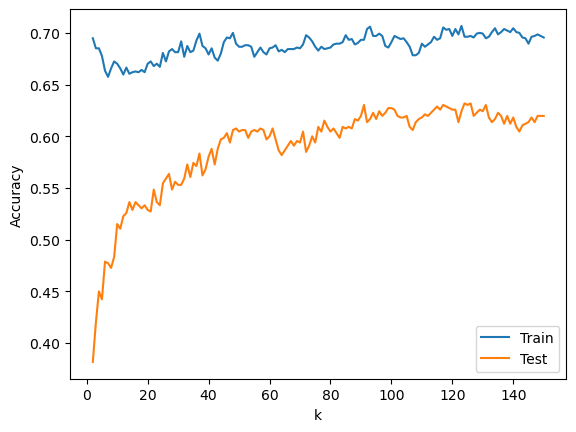

In [9]:
resultsKNN = pd.DataFrame(columns=['k', 'Train', 'Test'])

for k in range(2,151):
    knn = KNeighborsClassifier(n_neighbors=k, p=1)
    knn.fit(X_train, Y_train)

    train_acc = accuracy_score(Y_train, knn.predict(X_train))
    test_acc = accuracy_score(Y_test, knn.predict(X_test))

    resultsKNN.loc[k] = [k, train_acc, test_acc]

print(resultsKNN)
resultsKNN.set_index('k').plot()
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.show()

In [10]:
print('Best k =', resultsKNN['Test'].idxmax(),'Accuracy score =' ,resultsKNN['Test'].max())

Best k = 124 Accuracy score = 0.6318181818181818


## Interpretation.

The most suitable k value is k = 124, since it achieves the highest testing accuracy (0.6318). In general, the best performance occurs in the range of 100–130, where the testing accuracy is both high and stable (around 0.63–0.64). Smaller k values result in lower accuracy due to overfitting, while very large k values start to slightly decrease performance. Therefore, a moderately large k provides the best balance between bias and variance for this dataset.

## Q5. Impact of Minkowski orders on kNN Classifiers (20 points)

In this part, you will repeat the same experiment in Q4 (i.e., find how changing $k$ impact the accuracy) in combination with Minkowski order parameter (`p`). In other words, you will use the generalized Minkowski distance instead of the default Euclidean distance (where $p = 2$), which can be calculated as

$Minkowski(q, ins, p) = (\sum( |q_j-ins_j|^p ))^{\frac{1}{p}}$


For each $k \in [2, 150]$ and for each $p \in [1,4]$ find the training and testing accuracy scores. You can do that by alternating `p` and `n_neighbors` parameters in `KNeighborsClassifier`.

Similar to Q3, collect training and testing accuracy scores and plot 4 line charts for each different value of `p`.

Overall, which Minkowski order value is better? Why?

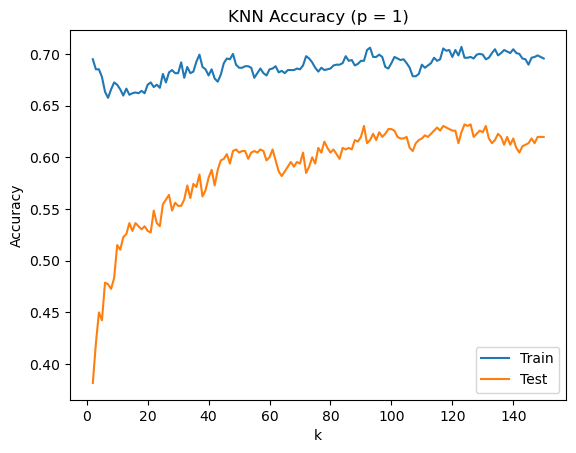

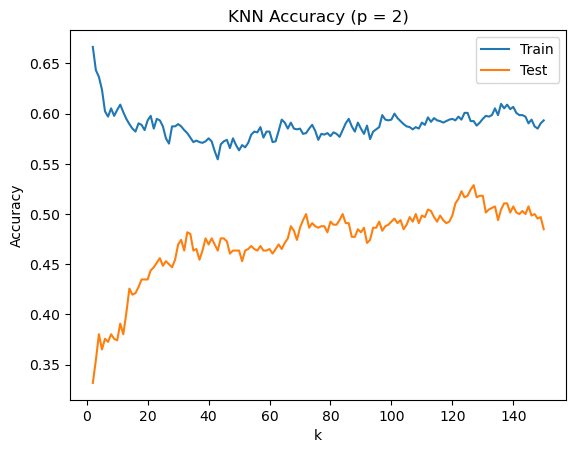

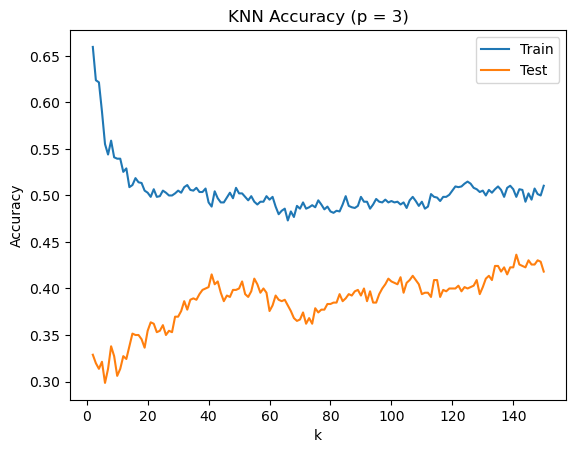

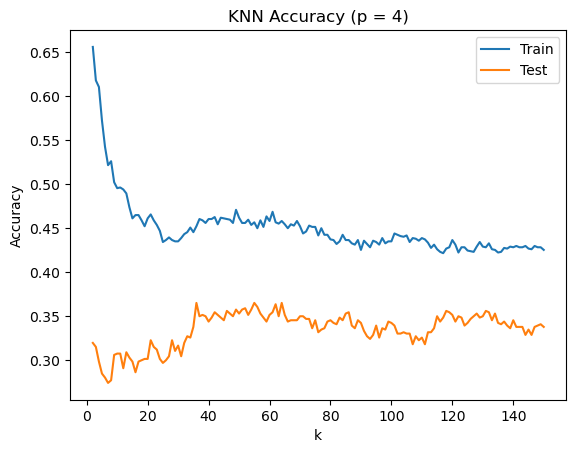

In [11]:
for p_val in range(1, 5):
    resultsKNN = pd.DataFrame(columns=['k', 'Train', 'Test'])
    
    for k in range(2, 151):
        knn = KNeighborsClassifier(n_neighbors=k, p=p_val, metric='minkowski')
        knn.fit(X_train, Y_train)

        train_acc = accuracy_score(Y_train, knn.predict(X_train))
        test_acc = accuracy_score(Y_test, knn.predict(X_test))

        resultsKNN.loc[k] = [k, train_acc, test_acc]
    
    resultsKNN.set_index('k')[['Train', 'Test']].plot()
    plt.title(f'KNN Accuracy (p = {p_val})')
    plt.xlabel('k')
    plt.ylabel('Accuracy')
    plt.show()

# Interpretation.
Overall, p = 1 performs the best since it achieves the highest testing accuracy across different values of k (around 0.62–0.63). As p increases, the testing accuracy consistently decreases, with p = 4 giving the worst results. This suggests that the Manhattan distance (p = 1) is more suitable for this dataset, since it provides better generalization compared to higher-order Minkowski distances.

# PART B -  Model Evaluation (30 PTS + 10 BONUS)

In this part, your friends in forecast department are in trouble and you will help them implement a number of performance metrics used in evaluating their forecasts.

There are many types of forecasts, each of which calls for slightly different methods of verification. Your friends are primarily interested in dichotomous forecasts. Quick research leads you to the fact that it is essentially binary prediction.

Their terminology is slightly different. Following are the differences:
- Instead of True Positives (TP) --> they use _Hits_ (a),
- Instead of False Positives (FP) --> they use _False Alarms_ (b)
- Instead of False Negatives (FN) --> they use _Misses_ (c),
- Instead of True Negatives (TN) --> they use _Correct Rejects_ (d).

For every single model run, you are given:
1. a set of observations (Event [1] or No Event [0])
2. a set of prediction scores (a float between 0 and 1) and an event threshold, where the predicted outcome will be

<center>$\hat{y}=
\begin{cases}
    1 \text{ (Event occurred)},& \text{if } score \geq threshold\\
    0 \text{ (No event),}      & \text{if } score < threshold
\end{cases} $ <center>

Note that observations are ground truth and prediction scores and threshold will be used for determining the predicted model output.

In [12]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Here are some test data you can use for this homework
Y_test = [0, 0, 1, 1, 0, 1, 0, 0, 0, 1] # observations
P_scores = [0.1, 0.32, 0.48, 0.9, 0.6, 0.55, 0.42, 0.37, 0.61, 0.66] # prediction scores
threshold = 0.5 # prediction threshold


## Question 1 (5 points)
Given prediction scores, threshold, and observations create a function to determine the elements of a confusion matrix. For ease of use, you will output a `dict` (dictionary) object instead of a 2-dimensional numpy array. Note that _positive_ corresponds to the event occurrence.

    '''Finds the entries (TP, FP, FN, TN) in a binary confusion matrix for forecast problems

    Parameters
    ----------
    observation: list
        list of observations (1 is there is event, 0 is there is no event)
    p_scores: list
        list of prediction scores (scores vary between 0 and 1)
    threshold: float
        threshold that will be used for binary outcome from prediction scores
    Returns
    -------
    dict
        a dictionary that shows the counts for TP, TN, FP, and FNs.

    '''

In [13]:
def binary_conf_matrix(observation, p_scores, threshold):
    tp = fp = fn = tn = 0

    for i in range(len(observation)):
        y = observation[i]
        score = p_scores[i]
        
        pred = 1 if score >= threshold else 0

        if pred == 1 and y == 1:
            tp += 1
        elif pred == 1 and y == 0:
            fp += 1
        elif pred == 0 and y == 1:
            fn += 1
        else:
            tn += 1

    return {'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn}

binary_conf_matrix(Y_test, P_scores, threshold)

{'TP': 3, 'TN': 4, 'FP': 2, 'FN': 1}

## Question 2 (10 points)

Create functions for calculating accuracy, precision, recall, and F1-score. You can use the definitions from slides (Model Evaluation - I). (You are supposed to calculate the precision and recall (and thus F1-score) for 'Event' [1] class.)

In [14]:
def accuracy(observation, p_scores, threshold):
    cm = binary_conf_matrix(observation, p_scores, threshold)
    tp = cm['TP']
    tn = cm['TN']
    fp = cm['FP']
    fn = cm['FN']
    if tp + tn + fp + fn >0:
        return (tp + tn) / (tp + tn + fp + fn)
    else:
        return 0

def precision(observation, p_scores, threshold):
    cm = binary_conf_matrix(observation, p_scores, threshold)
    tp =  cm['TP']
    tn = cm['TN']
    fp = cm['FP']
    fn = cm['FN']
    if tp + fp > 0:
        return tp/(tp+fp)
    else:
        return 0

def recall(observation, p_scores, threshold):
    cm = binary_conf_matrix(observation, p_scores, threshold)
    tp =  cm['TP']
    tn = cm['TN']
    fp = cm['FP']
    fn = cm['FN']
    if tp + fn > 0:
        return tp/(tp+fn)
    else:
        return 0
    
def f1score(observation, p_scores, threshold):
    p = precision(observation, p_scores, threshold)
    r = recall(observation, p_scores, threshold)
    if p+r > 0:
        return round((2 * p * r) / (p + r),2)
    else:
        return 0

print('Accuracy: ',accuracy(Y_test, P_scores, threshold))
print('precision: ',precision(Y_test, P_scores, threshold))
print('Recall: ',recall(Y_test, P_scores, threshold))
print('F1 Score: ',f1score(Y_test, P_scores, threshold))

Accuracy:  0.7
precision:  0.6
Recall:  0.75
F1 Score:  0.67


## Question 3 (5 points)
Calculate the bias score (BIAS). Bias score measures the ratio of the frequency of predicted event occurrences to the frequency of observed events. It can be calculated using the following formula:

$ BIAS = \frac{\text{hits} + \text{false alarms} }{ \text{hits} + \text{misses} }$

In [15]:
def bias_score(observation, p_scores, threshold):
    cm = binary_conf_matrix(observation, p_scores, threshold)
    tp = cm['TP']
    tn = cm['TN']
    fp = cm['FP']
    fn = cm['FN']

    if (tp + fn) > 0:
        return round((tp + fp) / (tp + fn), 2)
    else:
        return 0
        
bias_score(Y_test, P_scores, threshold)

1.25

## Question 4 (5 points)
Calculate the threat score. Threat score (which is also referred to as critical success index -- CSI) indicates how well did the predicted event outcomes correspond to the observed events. It measures the fraction of actual __and/or__ predicted events that were correctly predicted. It can be thought of as the accuracy when the correct negatives (TN) have been removed from consideration. It can be calculated as follows:

$CSI = \frac{ \text{hits} }{ \text{hits} + \text{misses} + \text{false alarms} } $


Instead of True Positives (TP) --> they use Hits (a),
Instead of False Positives (FP) --> they use False Alarms (b)
Instead of False Negatives (FN) --> they use Misses (c),
Instead of True Negatives (TN) --> they use Correct Rejects (d).


In [16]:
def csi(observation, p_scores, threshold):
    cm = binary_conf_matrix(observation, p_scores, threshold)
    tp = cm['TP']
    fp = cm['FP']
    fn = cm['FN']
    
    if (tp + fn + fp) > 0:
        return tp / (tp + fn + fp)
    else:
        return 0
        
csi(Y_test, P_scores, threshold)

0.5

## Question 5 (5 points)
The next skill score to calculate is Gilbert Skill Score (also known as Equitable Threat Score). This is an interesting indicator of performance because it measures the fraction of observed and/or predicted events that were correctly predicted, adjusted for hits (correctly predicted events) associated with random chance. For example, it is easier to correctly predict rain occurrence in a wet climate than in a dry climate. In other words, GSS can answer how well the predicted event occurrences correspond to the observed events (accounting for correct predictions appearing due to chance). The Gilbert Skill Score can be calculated as follows:

$GSS = \frac{ \text{hits} - \text{hits}_{random}}{ \text{hits} + \text{misses} + \text{false alarms} - \text{hits}_{random} } $

where the random hits can ba calculated as:

$ \text{hits}_{random} = \frac{ (\text{hits}+\text{misses} )* (\text{hits}+\text{false alarms} )}{total} $.

_total_ is sum of all the elements in confusion matrix.

Hint: Notice the similarity between GSS and threat score.

In [17]:
def gss(observation, p_scores, threshold):
    cm = binary_conf_matrix(observation, p_scores, threshold)
    tp = cm['TP']  # hit
    tn = cm['TN']  # correct rejection
    fp = cm['FP']  # false alarm
    fn = cm['FN']  # miss
    
    total = tp + tn + fp + fn

    if total > 0:
        hit_rand = ((tp + fn) * (tp + fp)) / total
    else:
        hit_rand = 0

    denom = tp + fn + fp - hit_rand

    if denom == 0:
        return 0
    else:
        return (tp - hit_rand) / denom
        
gss(Y_test, P_scores, threshold)

0.25

## Bonus Question (10 points)

Your last task is to determine an optimal threshold based on prediction scores, observations, and a given performance measure. Create a function called `pick_threshold` which will pick the best prediction score threshold (that will return the highest performance measure based on the given performance metric). Hint: Python allows you to pass a (performance measure) function (such as `gss`, `csi`, or `f1score`) to `pick_threshold`.

In [18]:
def pick_threshold(observation, p_scores, mfunc):
    best_t = 0
    best_score = -1
    
    for t in p_scores:  
        score = mfunc(observation, p_scores, t)
        
        if score > best_score:
            best_score = score
            best_t = t

    return best_t

pick_threshold(Y_test, P_scores, gss)

0.48